# Pricing and Risk Management of a Callable Bond

This project develops a framework for pricing and analyzing the risk of a callable fixed-rate bond.

The objective is to understand how the embedded call option affects the bond's value and risk profile, particularly its exposure to interest rates and interest-rate volatility.

The project will focus on:

- pricing a standard fixed-rate bond;
- modelling the evolution of interest rates;
- pricing the embedded call option;
- valuing the callable bond;
- analyzing interest-rate and volatility sensitivities;
- interpreting the results from a trading and risk-management perspective.

## 1. Financial Background

A callable bond is a bond that gives the **issuer** the right to redeem the bond before its contractual maturity on predetermined call dates and at predetermined call prices.

From the investor's perspective, a callable bond can be decomposed as:

$$
\text{Callable Bond}
=
\text{Straight Bond}
-
\text{Issuer Call Option}
$$

The embedded call option becomes particularly valuable to the issuer when interest rates decline. In that environment, the issuer may redeem the existing bond and potentially refinance its debt at a lower interest rate.

As a result, the call feature limits the upside of the bond for the investor when interest rates fall.

## 2. Straight Bond Pricing

Before introducing the embedded call option, we first consider an equivalent non-callable fixed-rate bond.

The value of a straight bond is equal to the present value of its future cash flows:

$$
P_{\text{straight}}
=
\sum_{i=1}^{n}
C_i\,D(0,t_i)
+
N\,D(0,T)
$$

where:

- $C_i$ is the coupon paid at time $t_i$;
- $N$ is the notional (face value) of the bond;
- $T$ is the maturity;
- $D(0,t)$ is the discount factor from time $t$ to today.

Under a constant continuously compounded interest rate $r$:

$$
D(0,t)=e^{-rt}
$$

and therefore:

$$
P_{\text{straight}}
=
\sum_{i=1}^{n} C_i e^{-rt_i}
+
N e^{-rT}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Bond characteristics
notional = 100
coupon_rate = 0.05
maturity = 5
frequency = 1

# Annual coupon payment
coupon = notional * coupon_rate / frequency

print(f"Notional: {notional}")
print(f"Annual coupon: {coupon}")
print(f"Maturity: {maturity} years")

Notional: 100
Annual coupon: 5.0
Maturity: 5 years


In [3]:
payment_times = np.arange(
    1 / frequency,
    maturity + 1 / frequency,
    1 / frequency
)

print(payment_times)

[1. 2. 3. 4. 5.]


In [4]:
# Constant continuously compounded interest rate
interest_rate = 0.05

# Discount factor for each payment date
discount_factors = np.exp(-interest_rate * payment_times)

print(discount_factors)

[0.95122942 0.90483742 0.86070798 0.81873075 0.77880078]


In [5]:
# Present value of all coupon payments
pv_coupons = np.sum(coupon * discount_factors)

print(f"PV of coupons: {pv_coupons:.4f}")

PV of coupons: 21.5715


In [6]:
# Present value of the principal repayment
pv_notional = notional * np.exp(-interest_rate * maturity)

print(f"PV of notional: {pv_notional:.4f}")

PV of notional: 77.8801


In [7]:
straight_bond_price = pv_coupons + pv_notional

print(f"Straight bond price: {straight_bond_price:.4f}")

Straight bond price: 99.4516


In [8]:
def price_straight_bond(
    notional,
    coupon_rate,
    maturity,
    interest_rate,
    frequency=1
):
    """
    Price a fixed-rate straight bond assuming a constant
    continuously compounded interest rate.

    Parameters
    ----------
    notional : float
        Face value of the bond.

    coupon_rate : float
        Annual coupon rate expressed as a decimal.

    maturity : float
        Time to maturity in years.

    interest_rate : float
        Constant continuously compounded interest rate.

    frequency : int
        Number of coupon payments per year.

    Returns
    -------
    float
        Present value of the bond.
    """

    coupon = notional * coupon_rate / frequency

    payment_times = np.arange(
        1 / frequency,
        maturity + 1 / frequency,
        1 / frequency
    )

    discount_factors = np.exp(
        -interest_rate * payment_times
    )

    pv_coupons = np.sum(
        coupon * discount_factors
    )

    pv_notional = notional * np.exp(
        -interest_rate * maturity
    )

    bond_price = pv_coupons + pv_notional

    return bond_price

In [9]:
price_3 = price_straight_bond(100, 0.05, 5, 0.03)
price_5 = price_straight_bond(100, 0.05, 5, 0.05)
price_7 = price_straight_bond(100, 0.05, 5, 0.07)

print(price_3)
print(price_5)
print(price_7)

108.93964597023678
99.45161008269608
90.83284963411825


In [10]:
# Interest rates from 0% to 10%
interest_rates = np.linspace(0.00, 0.10, 101)

print(interest_rates)

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1  ]


In [11]:
bond_prices = []

for rate in interest_rates:

    price = price_straight_bond(
        notional=100,
        coupon_rate=0.05,
        maturity=5,
        interest_rate=rate,
        frequency=1
    )

    bond_prices.append(price)

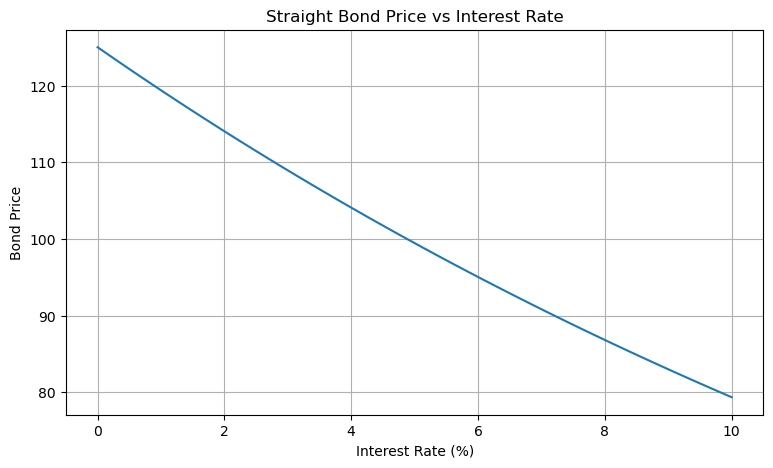

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    interest_rates * 100,
    bond_prices
)

plt.xlabel("Interest Rate (%)")
plt.ylabel("Bond Price")
plt.title("Straight Bond Price vs Interest Rate")

plt.grid(True)

plt.show()

## 3. Yield Curve and Discount Factors

In practice, bond cash flows are not generally discounted using a single constant interest rate.

Instead, the market provides a term structure of interest rates, where the discount rate depends on the maturity of the cash flow.

The price of a straight bond can therefore be written as:

$$
P_{\text{straight}}
=
\sum_{i=1}^{n} C_i D(0,t_i)
+
N D(0,T)
$$

where $D(0,t)$ represents the market discount factor for maturity $t$.

Under continuously compounded zero rates $z(0,t)$:

$$
D(0,t)=e^{-z(0,t)t}
$$

Therefore:

$$
P_{\text{straight}}
=
\sum_{i=1}^{n}
C_i e^{-z(0,t_i)t_i}
+
N e^{-z(0,T)T}
$$

In [13]:
# Maturities of the zero-coupon curve
curve_maturities = np.array([
    1, 2, 3, 4, 5
])

# Continuously compounded zero rates
zero_rates = np.array([
    0.025,
    0.028,
    0.031,
    0.033,
    0.035
])

print(zero_rates)

[0.025 0.028 0.031 0.033 0.035]


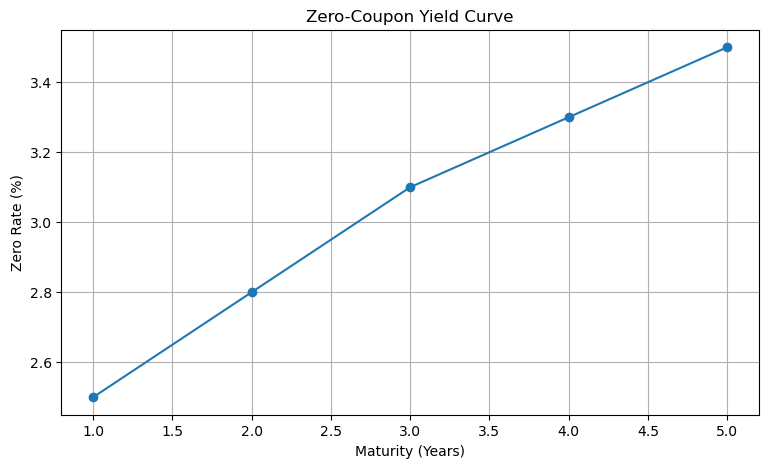

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_maturities,
    zero_rates * 100,
    marker="o"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate (%)")
plt.title("Zero-Coupon Yield Curve")

plt.grid(True)

plt.show()

In [15]:
discount_factors_curve = np.exp(
    -zero_rates * curve_maturities
)

print(discount_factors_curve)

[0.97530991 0.94553914 0.9111935  0.876341   0.83945702]


In [16]:
def price_bond_from_curve(
    notional,
    coupon_rate,
    maturity,
    frequency,
    curve_maturities,
    zero_rates
):
    """
    Price a fixed-rate bond using a zero-coupon yield curve.

    Parameters
    ----------
    notional : float
        Face value of the bond.

    coupon_rate : float
        Annual coupon rate expressed as a decimal.

    maturity : float
        Bond maturity in years.

    frequency : int
        Number of coupon payments per year.

    curve_maturities : array
        Maturities available on the zero-coupon curve.

    zero_rates : array
        Continuously compounded zero rates.

    Returns
    -------
    float
        Present value of the bond.
    """

    coupon = notional * coupon_rate / frequency

    payment_times = np.arange(
        1 / frequency,
        maturity + 1 / frequency,
        1 / frequency
    )

    rates = np.interp(
        payment_times,
        curve_maturities,
        zero_rates
    )

    discount_factors = np.exp(
        -rates * payment_times
    )

    pv_coupons = np.sum(
        coupon * discount_factors
    )

    pv_notional = notional * discount_factors[-1]

    bond_price = pv_coupons + pv_notional

    return bond_price

In [17]:
price_curve = price_bond_from_curve(
    notional=100,
    coupon_rate=0.05,
    maturity=5,
    frequency=1,
    curve_maturities=curve_maturities,
    zero_rates=zero_rates
)

print(f"Bond price using yield curve: {price_curve:.4f}")

Bond price using yield curve: 106.6849


In [18]:
shift = 0.01

higher_curve = zero_rates + shift
lower_curve = zero_rates - shift

In [19]:
price_base = price_bond_from_curve(
    100, 0.05, 5, 1,
    curve_maturities,
    zero_rates
)

price_up = price_bond_from_curve(
    100, 0.05, 5, 1,
    curve_maturities,
    higher_curve
)

price_down = price_bond_from_curve(
    100, 0.05, 5, 1,
    curve_maturities,
    lower_curve
)

print(f"Rates -100 bps: {price_down:.4f}")
print(f"Base curve:     {price_base:.4f}")
print(f"Rates +100 bps: {price_up:.4f}")

Rates -100 bps: 111.6662
Base curve:     106.6849
Rates +100 bps: 101.9375


## 4. Interest Rate Modelling

A static yield curve is sufficient to value deterministic bond cash flows, but it is not sufficient to value the embedded option of a callable bond.

At each call date, the issuer compares the call price with the economic value of keeping the bond outstanding. This decision therefore depends on the future state of interest rates.

We consequently need a stochastic interest-rate model capable of describing the evolution of rates through time.

## 5. Callable Bond Valuation by Backward Induction : A Simplified Example

A callable bond contains an early-exercise feature. Its value therefore depends not only on future cash flows, but also on the issuer's optimal exercise decision at each call date.

The bond is valued recursively from maturity back to the present.

At a non-call date, the bond value is the discounted expected continuation value plus any coupon payment.

At a call date, the issuer compares the continuation value of the bond with the contractual call price.

From the investor's perspective:

$$
V_t = \min(V_t^{\text{continuation}}, K_t)
$$

where $K_t$ is the call price.

If:

$$
V_t^{\text{continuation}} > K_t
$$

the issuer optimally exercises the call and redeems the bond.

If:

$$
V_t^{\text{continuation}} \leq K_t
$$

the bond remains outstanding.

### 5.1 Simplified Interest Rate Tree

To value the callable bond by backward induction, we represent the future evolution of interest rates using a discrete interest-rate tree.

Each node represents a possible future state of the short rate.

The tree allows the bond to be valued recursively while incorporating the issuer's exercise decision at each contractual call date.

In [20]:
# Simple interest-rate tree parameters
r0 = 0.05
rate_step = 0.01
n_steps = 3

In [21]:
rate_tree = []

for i in range(n_steps + 1):

    rates_at_time_i = []

    for j in range(i + 1):

        rate = r0 + (2 * j - i) * rate_step

        rates_at_time_i.append(rate)

    rate_tree.append(rates_at_time_i)

print(rate_tree)

[[0.05], [0.04, 0.060000000000000005], [0.030000000000000002, 0.05, 0.07], [0.020000000000000004, 0.04, 0.060000000000000005, 0.08]]


In [22]:
for i, rates in enumerate(rate_tree):

    formatted_rates = [
        f"{rate * 100:.1f}%"
        for rate in rates
    ]

    print(f"t={i}: {formatted_rates}")

t=0: ['5.0%']
t=1: ['4.0%', '6.0%']
t=2: ['3.0%', '5.0%', '7.0%']
t=3: ['2.0%', '4.0%', '6.0%', '8.0%']


### 5.2 Straight Bond Valuation on the Tree

Before introducing the call feature, the straight bond is valued recursively through the interest-rate tree.

At each node, the bond value is equal to the discounted risk-neutral expected value of the bond at the next time step, plus the coupon payment.

Under the simplified assumption of equal risk-neutral probabilities:

$$
p = 1-p = 0.5
$$

the ex-coupon bond value at node $(i,j)$ is:

$$
V_{i,j}
=
e^{-r_{i,j}\Delta t}
\left[
pV_{i+1,j+1}
+
(1-p)V_{i+1,j}
+
C
\right]
$$

The valuation proceeds backwards from maturity to the present.

In [23]:
# Bond parameters for the tree example
notional_tree = 100
coupon_rate_tree = 0.05
coupon_tree = notional_tree * coupon_rate_tree

dt = 1
p = 0.5

In [24]:
bond_tree = [
    [] for _ in range(n_steps + 1)
]

# Terminal redemption value at maturity
bond_tree[n_steps] = [
    notional_tree
] * (n_steps + 1)

for i in range(n_steps - 1, -1, -1):

    values_at_time_i = []

    for j in range(i + 1):

        rate = rate_tree[i][j]

        expected_future_value = (
            p * bond_tree[i + 1][j + 1]
            + (1 - p) * bond_tree[i + 1][j]
        )

        bond_value = np.exp(-rate * dt) * (
            expected_future_value + coupon_tree
        )

        values_at_time_i.append(bond_value)

    bond_tree[i] = values_at_time_i

In [25]:
for i, values in enumerate(bond_tree):

    formatted_values = [
        f"{value:.2f}"
        for value in values
    ]

    print(f"t={i}: {formatted_values}")

t=0: ['99.68']
t=1: ['101.74', '97.84']
t=2: ['101.90', '99.88', '97.90']
t=3: ['100.00', '100.00', '100.00', '100.00']


### 5.3 Callable Bond Valuation

The callable bond is valued using backward induction.

We assume that call decisions are made immediately after coupon payments. At each call date, the issuer compares the ex-coupon continuation value of the bond with the contractual call price.

From the investor's perspective, the value at a call date is therefore:

$$
V_{i,j}^{\text{callable}}
=
\min
\left(
V_{i,j}^{\text{continuation}},
K_i
\right)
$$

where $K_i$ denotes the call price.

If the continuation value exceeds the call price, the issuer exercises the option and redeems the bond.

Otherwise, the bond remains outstanding.

In [26]:
call_price = 100

# Two years of call protection, then annually callable at par
call_dates = [
    2,
    3
]

In [27]:
# Initialize the callable bond value tree
callable_tree = [
    [] for _ in range(n_steps + 1)
]

# Initialize a second tree to record the issuer's exercise decisions
exercise_tree = [
    [] for _ in range(n_steps + 1)
]

# At maturity, the terminal redemption value is equal to the notional
callable_tree[n_steps] = [
    notional_tree
] * (n_steps + 1)

In [28]:
for i in range(n_steps - 1, -1, -1):

    values_at_time_i = []
    decisions_at_time_i = []

    for j in range(i + 1):

        rate = rate_tree[i][j]

        expected_future_value = (
            p * callable_tree[i + 1][j + 1]
            + (1 - p) * callable_tree[i + 1][j]
        )

        continuation_value = np.exp(-rate * dt) * (
            expected_future_value + coupon_tree
        )

        if i in call_dates:

            exercise = continuation_value > call_price

            bond_value = min(
                continuation_value,
                call_price
            )

        else:

            exercise = False
            bond_value = continuation_value

        values_at_time_i.append(bond_value)
        decisions_at_time_i.append(exercise)

    callable_tree[i] = values_at_time_i
    exercise_tree[i] = decisions_at_time_i

In [29]:
for i, values in enumerate(callable_tree):

    formatted_values = [
        f"{value:.2f}"
        for value in values
    ]

    print(f"t={i}: {formatted_values}")

t=0: ['99.24']
t=1: ['100.82', '97.84']
t=2: ['100.00', '99.88', '97.90']
t=3: ['100.00', '100.00', '100.00', '100.00']


In [30]:
for i in range(n_steps):

    print(f"\nt={i}")

    for j in range(i + 1):

        rate = rate_tree[i][j]
        exercise = exercise_tree[i][j]

        decision = "Call" if exercise else "No Call"

        print(
            f"Rate = {rate * 100:.1f}% "
            f"-> {decision}"
        )


t=0
Rate = 5.0% -> No Call

t=1
Rate = 4.0% -> No Call
Rate = 6.0% -> No Call

t=2
Rate = 3.0% -> Call
Rate = 5.0% -> No Call
Rate = 7.0% -> No Call


In [31]:
straight_price = bond_tree[0][0]
callable_price = callable_tree[0][0]

embedded_call_value = (
    straight_price - callable_price
)

print(
    f"Straight bond price: {straight_price:.4f}"
)

print(
    f"Callable bond price: {callable_price:.4f}"
)

print(
    f"Embedded call value: {embedded_call_value:.4f}"
)

Straight bond price: 99.6775
Callable bond price: 99.2441
Embedded call value: 0.4334


## 6. Hull–White One-Factor Model

The simplified interest-rate tree introduced in the previous section is useful for understanding backward induction and the issuer's optimal call decision. However, it does not provide a realistic model of the term structure of interest rates.

To obtain a more consistent framework, we use the one-factor Hull–White model:

$$
dr_t = [\theta(t) - a r_t]dt + \sigma dW_t
$$

where:

- $r_t$ is the instantaneous short rate;
- $a$ controls the speed of mean reversion;
- $\sigma$ is the short-rate volatility;
- $W_t$ is a Brownian motion;
- $\theta(t)$ is a deterministic function chosen to fit the initial term structure.

The Hull–White model is particularly suitable for callable bond pricing because it combines stochastic interest rates with consistency with the initial yield curve. This allows future bond values and optimal call decisions to be evaluated across different interest-rate states.

### 6.1 Model Dynamics

The Hull–White model is defined in continuous time as:

$$
dr_t = [\theta(t)-ar_t]dt+\sigma dW_t
$$

For numerical implementation, the process can be discretized over a small time interval $\Delta t$ as:

$$
r_{t+\Delta t}
\approx
r_t
+
[\theta(t)-ar_t]\Delta t
+
\sigma\sqrt{\Delta t}Z
$$

where:

$$
Z \sim \mathcal{N}(0,1)
$$

The first component represents the deterministic drift of the short rate, while the second introduces stochastic interest-rate shocks.

For callable bond valuation, we will use a tree-based implementation rather than a simple Monte Carlo simulation. This preserves the backward-induction framework introduced previously and allows the issuer's optimal call decision to be evaluated at each callable node.

### 6.2 Calibration to the Initial Yield Curve

A key advantage of the Hull–White model is its ability to reproduce the initial term structure of interest rates.

The model is calibrated so that the zero-coupon bond prices implied by Hull–White are consistent with the initial market discount curve:

$$
P^{HW}(0,T)=P^{Market}(0,T)
$$

The time-dependent drift term $\theta(t)$ allows the model to fit the initial yield curve.

Under the Hull–White specification used in this project:

$$
\theta(t)
=
\frac{\partial f(0,t)}{\partial t}
+
a f(0,t)
+
\frac{\sigma^2}{2a}
\left(1-e^{-2at}\right)
$$

where the instantaneous forward rate is obtained from the initial discount curve:

$$
f(0,t)
=
-\frac{\partial \ln P(0,t)}{\partial t}
$$

This creates the link between the initial yield curve and the stochastic interest-rate dynamics used to value the callable bond.

In a full market implementation, the mean-reversion parameter $a$ and volatility parameter $\sigma$ can be calibrated to interest-rate option prices such as swaptions. In this project, they will be treated as model parameters and their impact on the callable bond will later be analyzed through sensitivity tests.

In [32]:
# Create a fine time grid for the initial yield curve
curve_time_grid = np.linspace(
    0.0,
    maturity,
    501
)

# Interpolate zero rates across the time grid
interpolated_zero_rates = np.interp(
    curve_time_grid,
    curve_maturities,
    zero_rates
)

In [33]:
# Convert zero rates into discount factors
initial_discount_curve = np.exp(
    -interpolated_zero_rates * curve_time_grid
)

In [34]:
print(initial_discount_curve[:10])

[1.         0.99975003 0.99950012 0.99925028 0.9990005  0.99875078
 0.99850112 0.99825153 0.998002   0.99775253]


In [35]:
# Compute the instantaneous forward rate
forward_rates = -np.gradient(
    np.log(initial_discount_curve),
    curve_time_grid
)

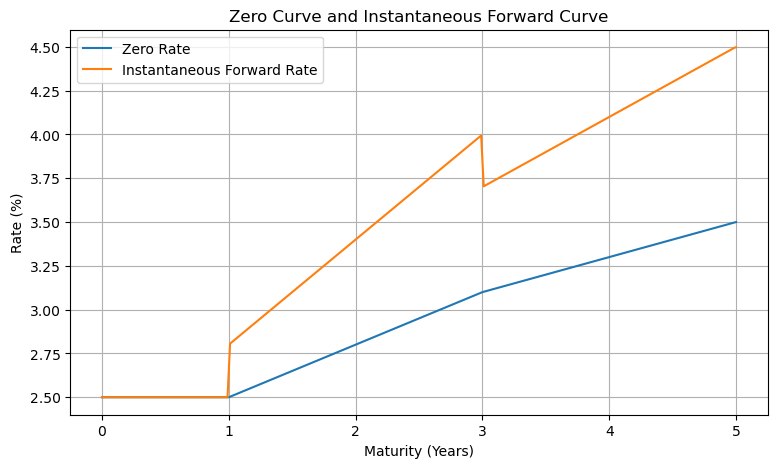

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_time_grid,
    interpolated_zero_rates * 100,
    label="Zero Rate"
)

plt.plot(
    curve_time_grid,
    forward_rates * 100,
    label="Instantaneous Forward Rate"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Rate (%)")
plt.title("Zero Curve and Instantaneous Forward Curve")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
from scipy.interpolate import CubicSpline

In [38]:
# Add a short-rate anchor at t = 0
curve_maturities_hw = np.insert(
    curve_maturities,
    0,
    0.0
)

zero_rates_hw = np.insert(
    zero_rates,
    0,
    zero_rates[0]
)

In [39]:
# Build a smooth cubic interpolation of the zero curve
zero_curve_spline = CubicSpline(
    curve_maturities_hw,
    zero_rates_hw,
    bc_type="natural"
)

# Evaluate the smooth zero curve on the fine time grid
smooth_zero_rates = zero_curve_spline(
    curve_time_grid
)

In [40]:
# First derivative of the smooth zero curve
zero_curve_derivative = zero_curve_spline.derivative(1)

dz_dt = zero_curve_derivative(
    curve_time_grid
)

# Instantaneous forward rate
smooth_forward_rates = (
    smooth_zero_rates
    + curve_time_grid * dz_dt
)

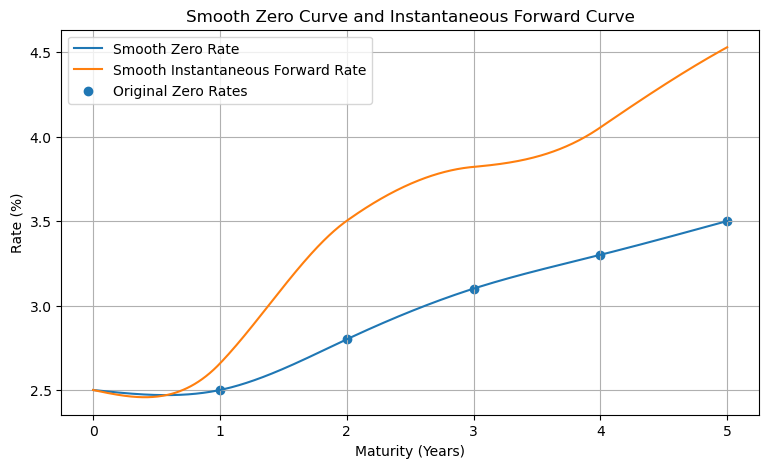

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_time_grid,
    smooth_zero_rates * 100,
    label="Smooth Zero Rate"
)

plt.plot(
    curve_time_grid,
    smooth_forward_rates * 100,
    label="Smooth Instantaneous Forward Rate"
)

plt.scatter(
    curve_maturities,
    zero_rates * 100,
    label="Original Zero Rates"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Rate (%)")
plt.title("Smooth Zero Curve and Instantaneous Forward Curve")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
# Hull-White model parameters
a = 0.10
sigma = 0.01

In [43]:
# Second derivative of the smooth zero curve
zero_curve_second_derivative = (
    zero_curve_spline.derivative(2)
)

d2z_dt2 = zero_curve_second_derivative(
    curve_time_grid
)

# Derivative of the instantaneous forward rate
df_dt = (
    2 * dz_dt
    + curve_time_grid * d2z_dt2
)

In [44]:
# Compute the Hull-White time-dependent drift
theta = (
    df_dt
    + a * smooth_forward_rates
    + (sigma**2 / (2 * a))
    * (
        1
        - np.exp(
            -2 * a * curve_time_grid
        )
    )
)

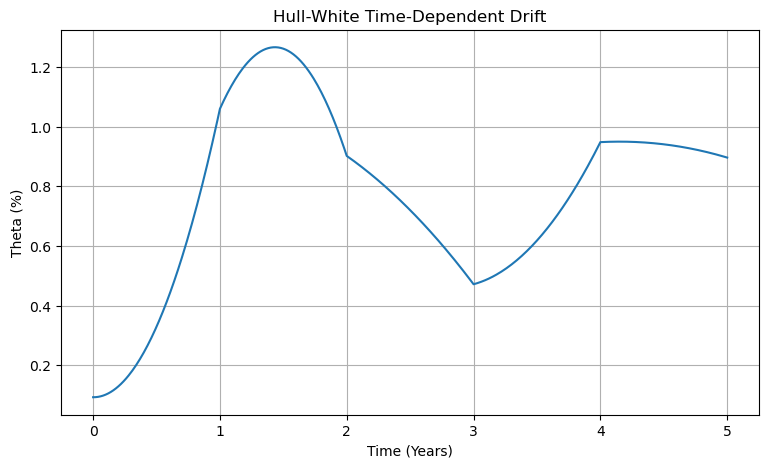

In [45]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_time_grid,
    theta * 100
)

plt.xlabel("Time (Years)")
plt.ylabel("Theta (%)")
plt.title("Hull-White Time-Dependent Drift")
plt.grid(True)

plt.show()

### 6.3 Hull–White Interest Rate Tree

To value the callable bond by backward induction, the continuous Hull–White dynamics must be represented on a discrete interest-rate tree.

The tree should satisfy two important properties:

1. **Recombination:** different interest-rate paths can lead to the same future node, keeping the number of states computationally manageable.

2. **Term-structure consistency:** the tree must reproduce the initial discount curve used to calibrate the model.

The Hull–White short rate can be represented as:

$$
r_{i,j} = x_{i,j} + \alpha_i
$$

where:

- $x_{i,j}$ represents the stochastic component of the short rate;
- $\alpha_i$ is a time-dependent shift used to ensure consistency with the initial term structure.

The tree will therefore separate the stochastic evolution of interest rates from the deterministic adjustment required to fit today's yield curve.

In [46]:
# Time discretization for the Hull-White tree
dt_hw = 0.5

n_steps_hw = int(
    maturity / dt_hw
)

print(f"Time step: {dt_hw} years")
print(f"Number of steps: {n_steps_hw}")

Time step: 0.5 years
Number of steps: 10


In [47]:
# Spacing between adjacent states of the stochastic component
dx = sigma * np.sqrt(
    3 * dt_hw
)

print(f"State spacing: {dx:.6f}")

State spacing: 0.012247


In [48]:
# Build the stochastic state grid
x_tree = []

for i in range(n_steps_hw + 1):

    states_at_time_i = []

    for j in range(-i, i + 1):

        x = j * dx

        states_at_time_i.append(x)

    x_tree.append(states_at_time_i)

In [49]:
for i in range(4):

    formatted_states = [
        f"{x * 100:.3f}%"
        for x in x_tree[i]
    ]

    print(
        f"t={i * dt_hw:.1f}: "
        f"{formatted_states}"
    )

t=0.0: ['0.000%']
t=0.5: ['-1.225%', '0.000%', '1.225%']
t=1.0: ['-2.449%', '-1.225%', '0.000%', '1.225%', '2.449%']
t=1.5: ['-3.674%', '-2.449%', '-1.225%', '0.000%', '1.225%', '2.449%', '3.674%']


#### Transition Probabilities

The stochastic component of the Hull–White model follows:

$$
dx_t=-ax_tdt+\sigma dW_t
$$

The trinomial tree uses three possible transitions from each node:

$$
\text{Down},\qquad \text{Middle},\qquad \text{Up}
$$

The transition probabilities are chosen to reproduce the local mean and variance of the Hull–White process.

The mean-reversion term $-ax_t$ makes upward movements relatively more likely when the current state is low and downward movements relatively more likely when the current state is high.

In [50]:
# Initialize the transition probability tree
transition_probabilities = []

for i in range(n_steps_hw):

    probabilities_at_time_i = []

    for j in range(-i, i + 1):

        x = j * dx

        # Mean-reversion drift expressed in units of dx
        m = (
            -a * x * dt_hw / dx
        )

        # Trinomial transition probabilities
        p_up = (
            1 / 6
            + 0.5 * (m**2 + m)
        )

        p_middle = (
            2 / 3
            - m**2
        )

        p_down = (
            1 / 6
            + 0.5 * (m**2 - m)
        )

        probabilities_at_time_i.append(
            (p_down, p_middle, p_up)
        )

    transition_probabilities.append(
        probabilities_at_time_i
    )

In [51]:
# Check that all transition probabilities sum to one
for i, probabilities in enumerate(
    transition_probabilities
):

    for probs in probabilities:

        total_probability = sum(probs)

        assert np.isclose(
            total_probability,
            1.0
        )

print(
    "All transition probabilities sum to 1."
)

All transition probabilities sum to 1.


In [52]:
# Display transition probabilities at t = 1 year
time_index = int(1.0 / dt_hw)

for position, probs in enumerate(
    transition_probabilities[time_index]
):

    j = position - time_index
    x = j * dx

    p_down, p_middle, p_up = probs

    print(
        f"x = {x * 100:.3f}% | "
        f"Down = {p_down:.3f}, "
        f"Middle = {p_middle:.3f}, "
        f"Up = {p_up:.3f}"
    )

x = -2.449% | Down = 0.122, Middle = 0.657, Up = 0.222
x = -1.225% | Down = 0.143, Middle = 0.664, Up = 0.193
x = 0.000% | Down = 0.167, Middle = 0.667, Up = 0.167
x = 1.225% | Down = 0.193, Middle = 0.664, Up = 0.143
x = 2.449% | Down = 0.222, Middle = 0.657, Up = 0.122


#### Calibration of the Tree to the Initial Term Structure

The stochastic tree determines the relative movements of interest rates, but it must also reproduce the initial market discount curve.

The short rate at each node is written as:

$$
r_{i,j}=x_{i,j}+\alpha_i
$$

where $\alpha_i$ is a deterministic shift applied to all nodes at time $t_i$.

To determine this shift, Arrow-Debreu state prices are propagated through the tree. The calibration condition requires the model-implied zero-coupon bond prices to match the initial discount curve:

$$
\sum_j Q_{i,j}=P(0,t_i)
$$

This ensures that the stochastic interest-rate tree remains consistent with today's term structure.

In [53]:
# Time points of the Hull-White tree
hw_times = np.arange(
    n_steps_hw + 1
) * dt_hw

# Market discount factors at the tree dates
market_discount_factors = np.exp(
    -zero_curve_spline(hw_times)
    * hw_times
)

In [54]:
for t, df in zip(
    hw_times,
    market_discount_factors
):
    print(
        f"t = {t:.1f} | "
        f"P(0,t) = {df:.6f}"
    )

t = 0.0 | P(0,t) = 1.000000
t = 0.5 | P(0,t) = 0.987723
t = 1.0 | P(0,t) = 0.975310
t = 1.5 | P(0,t) = 0.961379
t = 2.0 | P(0,t) = 0.945539
t = 2.5 | P(0,t) = 0.928583
t = 3.0 | P(0,t) = 0.911194
t = 3.5 | P(0,t) = 0.893842
t = 4.0 | P(0,t) = 0.876341
t = 4.5 | P(0,t) = 0.858213
t = 5.0 | P(0,t) = 0.839457


In [55]:
# Initialize Arrow-Debreu state prices
state_prices = [
    np.array([1.0])
]

# Store the calibrated deterministic shifts
alpha = []

In [56]:
for i in range(n_steps_hw):

    current_state_prices = state_prices[i]

    x_states = np.array(
        x_tree[i]
    )

    # Compute the deterministic shift alpha_i
    numerator = np.sum(
        current_state_prices
        * np.exp(
            -x_states * dt_hw
        )
    )

    alpha_i = (
        np.log(
            numerator
            / market_discount_factors[i + 1]
        )
        / dt_hw
    )

    alpha.append(alpha_i)

    # Initialize next-period state prices
    next_state_prices = np.zeros(
        2 * (i + 1) + 1
    )

    for position in range(
        len(x_tree[i])
    ):

        x = x_tree[i][position]

        short_rate = (
            x + alpha_i
        )

        discount = np.exp(
            -short_rate * dt_hw
        )

        p_down, p_middle, p_up = (
            transition_probabilities[i][position]
        )

        next_state_prices[position] += (
            current_state_prices[position]
            * discount
            * p_down
        )

        next_state_prices[position + 1] += (
            current_state_prices[position]
            * discount
            * p_middle
        )

        next_state_prices[position + 2] += (
            current_state_prices[position]
            * discount
            * p_up
        )

    state_prices.append(
        next_state_prices
    )

In [57]:
for i in range(
    n_steps_hw + 1
):

    model_df = np.sum(
        state_prices[i]
    )

    market_df = (
        market_discount_factors[i]
    )

    print(
        f"t={hw_times[i]:.1f} | "
        f"Market={market_df:.6f} | "
        f"Model={model_df:.6f} | "
        f"Error={model_df - market_df:.2e}"
    )

t=0.0 | Market=1.000000 | Model=1.000000 | Error=0.00e+00
t=0.5 | Market=0.987723 | Model=0.987723 | Error=1.11e-16
t=1.0 | Market=0.975310 | Model=0.975310 | Error=0.00e+00
t=1.5 | Market=0.961379 | Model=0.961379 | Error=0.00e+00
t=2.0 | Market=0.945539 | Model=0.945539 | Error=1.11e-16
t=2.5 | Market=0.928583 | Model=0.928583 | Error=1.11e-16
t=3.0 | Market=0.911194 | Model=0.911194 | Error=-1.11e-16
t=3.5 | Market=0.893842 | Model=0.893842 | Error=0.00e+00
t=4.0 | Market=0.876341 | Model=0.876341 | Error=-1.11e-16
t=4.5 | Market=0.858213 | Model=0.858213 | Error=1.11e-16
t=5.0 | Market=0.839457 | Model=0.839457 | Error=-2.22e-16


In [58]:
# Build the calibrated Hull-White short-rate tree
hw_rate_tree = []

for i in range(n_steps_hw):

    rates_at_time_i = []

    for x in x_tree[i]:

        short_rate = (
            x + alpha[i]
        )

        rates_at_time_i.append(
            short_rate
        )

    hw_rate_tree.append(
        rates_at_time_i
    )

In [59]:
for i in range(4):

    formatted_rates = [
        f"{rate * 100:.3f}%"
        for rate in hw_rate_tree[i]
    ]

    print(
        f"t={hw_times[i]:.1f}: "
        f"{formatted_rates}"
    )

t=0.0: ['2.471%']
t=0.5: ['1.306%', '2.531%', '3.755%']
t=1.0: ['0.433%', '1.657%', '2.882%', '4.107%', '5.332%']
t=1.5: ['-0.341%', '0.883%', '2.108%', '3.333%', '4.558%', '5.782%', '7.007%']


## 7. Callable Bond Pricing

The calibrated Hull–White tree can now be used to value the bond by backward induction.

We first price the corresponding straight bond. This provides a benchmark before introducing the issuer's call option.

At each node, the bond value is obtained from the current cash flow and the discounted risk-neutral expected value of the bond at the next time step.

Under the cash-flow convention used in the implementation:

$$
V_{i,j}
=
C_i
+
e^{-r_{i,j}\Delta t}
\mathbb{E}^{Q}_{i,j}
\left[
V_{i+1}
\right]
$$

with the terminal condition:

$$
V_T = N + C_T.
$$

The expectation is computed using the trinomial transition probabilities of the Hull–White tree.

### 7.1 Straight Bond Valuation

In [60]:
# Create the bond cash flows on the Hull-White time grid
bond_cash_flows = np.zeros(
    n_steps_hw + 1
)

for i, t in enumerate(hw_times):

    # Annual coupon payments
    if (
        t > 0
        and np.isclose(
            t % 1.0,
            0.0
        )
    ):
        bond_cash_flows[i] += coupon_tree

# Principal repayment at maturity
bond_cash_flows[-1] += notional_tree

In [61]:
for t, cash_flow in zip(
    hw_times,
    bond_cash_flows
):

    print(
        f"t={t:.1f} | "
        f"Cash flow={cash_flow:.2f}"
    )

t=0.0 | Cash flow=0.00
t=0.5 | Cash flow=0.00
t=1.0 | Cash flow=5.00
t=1.5 | Cash flow=0.00
t=2.0 | Cash flow=5.00
t=2.5 | Cash flow=0.00
t=3.0 | Cash flow=5.00
t=3.5 | Cash flow=0.00
t=4.0 | Cash flow=5.00
t=4.5 | Cash flow=0.00
t=5.0 | Cash flow=105.00


In [62]:
# Initialize the straight bond value tree
straight_hw_tree = [
    None
    for _ in range(
        n_steps_hw + 1
    )
]

# Final coupon and principal are paid at maturity
straight_hw_tree[-1] = np.full(
    len(x_tree[-1]),
    bond_cash_flows[-1]
)

In [63]:
# Price the straight bond by backward induction
for i in range(
    n_steps_hw - 1,
    -1,
    -1
):

    values_at_time_i = []

    for position in range(
        len(hw_rate_tree[i])
    ):

        rate = (
            hw_rate_tree[i][position]
        )

        p_down, p_middle, p_up = (
            transition_probabilities[i][position]
        )

        next_values = (
            straight_hw_tree[i + 1]
        )

        expected_future_value = (
            p_down
            * next_values[position]
            + p_middle
            * next_values[position + 1]
            + p_up
            * next_values[position + 2]
        )

        bond_value = np.exp(
            -rate * dt_hw
        ) * expected_future_value

        # Add the coupon paid at the current date
        bond_value += (
            bond_cash_flows[i]
        )

        values_at_time_i.append(
            bond_value
        )

    straight_hw_tree[i] = np.array(
        values_at_time_i
    )

In [64]:
straight_hw_price = (
    straight_hw_tree[0][0]
)

print(
    f"Hull-White straight bond price: "
    f"{straight_hw_price:.4f}"
)

print(
    f"Yield-curve straight bond price: "
    f"{price_curve:.4f}"
)

Hull-White straight bond price: 106.6849
Yield-curve straight bond price: 106.6849


### 7.2 Callable Bond Valuation

The callable bond is valued using the same backward-induction framework as the straight bond, with one additional feature: at each call date, the issuer can redeem the bond at the contractual call price.

Under the cash-flow convention used in this implementation, the call decision is made after the coupon payment at the current date. The ex-coupon continuation value is therefore:

$$
V_{i,j}^{Continuation}
=
e^{-r_{i,j}\Delta t}
\mathbb{E}^{Q}_{i,j}
\left[
V_{i+1}^{Callable}
\right].
$$

At a callable node, the issuer compares this continuation value with the contractual call price $K_i$.

The ex-coupon value of the callable bond is:

$$
V_{i,j}^{Ex\text{-}Coupon}
=
\min
\left(
V_{i,j}^{Continuation},
K_i
\right).
$$

The full value at the node, including the coupon paid at the current date, is therefore:

$$
V_{i,j}^{Callable}
=
C_i
+
\min
\left(
V_{i,j}^{Continuation},
K_i
\right).
$$

The issuer exercises the call whenever:

$$
V_{i,j}^{Continuation}>K_i,
$$

because the issuer can retire debt worth more than the contractual call price by paying only $K_i$.

At dates that are not callable, the bond value is simply:

$$
V_{i,j}^{Callable}
=
C_i
+
V_{i,j}^{Continuation}.
$$

This exercise feature introduces non-linearity into the bond valuation and makes the callable bond sensitive to both interest rates and interest-rate volatility.

The bond considered in this project has a five-year maturity and two years of call protection. After the non-call period, the issuer may redeem the bond at par on each annual coupon payment date:

$$
\text{Call Dates} = \{2Y,3Y,4Y\},
\qquad
K=100.
$$

Because the call dates coincide with coupon payment dates, the coupon due on the exercise date is paid to the investor together with the contractual call price. Therefore, if the bond is called on a coupon date, the investor receives:

$$
K + C = 100 + 5 = 105.
$$

This convention provides a simple representation of a market-style callable structure while avoiding additional settlement and accrued-interest conventions.

In [65]:
# Callable bond characteristics
call_price_hw = 100

# 5Y NC2 bond: two years of call protection,
# then annually callable at par on coupon dates
call_dates_hw = [
    2.0,
    3.0,
    4.0
]

In [66]:
# Initialize callable bond and exercise trees
callable_hw_tree = [
    None
    for _ in range(
        n_steps_hw + 1
    )
]

exercise_hw_tree = [
    None
    for _ in range(
        n_steps_hw + 1
    )
]

# Final coupon and principal at maturity
callable_hw_tree[-1] = np.full(
    len(x_tree[-1]),
    bond_cash_flows[-1]
)

In [67]:
# Price the callable bond by backward induction
for i in range(
    n_steps_hw - 1,
    -1,
    -1
):

    values_at_time_i = []
    decisions_at_time_i = []

    for position in range(
        len(hw_rate_tree[i])
    ):

        rate = (
            hw_rate_tree[i][position]
        )

        p_down, p_middle, p_up = (
            transition_probabilities[i][position]
        )

        next_values = (
            callable_hw_tree[i + 1]
        )

        expected_future_value = (
            p_down
            * next_values[position]
            + p_middle
            * next_values[position + 1]
            + p_up
            * next_values[position + 2]
        )

        # Ex-coupon continuation value
        continuation_value = np.exp(
            -rate * dt_hw
        ) * expected_future_value

        current_time = hw_times[i]

        # Check whether the current date is callable
        is_call_date = any(
            np.isclose(
                current_time,
                call_date
            )
            for call_date in call_dates_hw
        )

        if is_call_date:

            exercise = (
                continuation_value
                > call_price_hw
            )

            ex_coupon_value = min(
                continuation_value,
                call_price_hw
            )

        else:

            exercise = False
            ex_coupon_value = (
                continuation_value
            )

        # Coupon paid at the current date
        bond_value = (
            ex_coupon_value
            + bond_cash_flows[i]
        )

        values_at_time_i.append(
            bond_value
        )

        decisions_at_time_i.append(
            exercise
        )

    callable_hw_tree[i] = np.array(
        values_at_time_i
    )

    exercise_hw_tree[i] = np.array(
        decisions_at_time_i
    )

In [68]:
callable_hw_price = (
    callable_hw_tree[0][0]
)

embedded_call_hw_value = (
    straight_hw_price
    - callable_hw_price
)

print(
    f"Straight bond price: "
    f"{straight_hw_price:.4f}"
)

print(
    f"Callable bond price: "
    f"{callable_hw_price:.4f}"
)

print(
    f"Embedded call value: "
    f"{embedded_call_hw_value:.4f}"
)

Straight bond price: 106.6849
Callable bond price: 103.6340
Embedded call value: 3.0509


#### Exercise Decisions

The optimal exercise policy can be examined directly from the Hull–White tree.

At each callable node, the issuer compares the ex-coupon continuation value of the bond with the contractual call price.

The bond is called whenever:

$$
V_{i,j}^{Continuation}>K
$$

Lower interest rates generally increase the value of the remaining fixed coupon payments. As a result, the issuer is more likely to call the bond in low-interest-rate states.

This exercise mechanism limits the upside of the callable bond when interest rates decline.

In [69]:
# Display exercise decisions at each call date
for i, current_time in enumerate(hw_times[:-1]):

    if any(
        np.isclose(current_time, call_date)
        for call_date in call_dates_hw
    ):

        print(f"\nCall date: t={current_time:.1f}")

        for position in range(
            len(hw_rate_tree[i])
        ):

            rate = hw_rate_tree[i][position]

            p_down, p_middle, p_up = (
                transition_probabilities[i][position]
            )

            next_values = callable_hw_tree[i + 1]

            expected_future_value = (
                p_down * next_values[position]
                + p_middle * next_values[position + 1]
                + p_up * next_values[position + 2]
            )

            continuation_value = np.exp(
                -rate * dt_hw
            ) * expected_future_value

            exercise = (
                exercise_hw_tree[i][position]
            )

            decision = (
                "Call"
                if exercise
                else "No Call"
            )

            print(
                f"Rate = {rate * 100:6.3f}% | "
                f"Continuation = {continuation_value:7.3f} | "
                f"{decision}"
            )


Call date: t=2.0
Rate = -1.263% | Continuation = 106.114 | Call
Rate = -0.038% | Continuation = 104.855 | Call
Rate =  1.187% | Continuation = 103.610 | Call
Rate =  2.412% | Continuation = 102.350 | Call
Rate =  3.636% | Continuation = 100.893 | Call
Rate =  4.861% | Continuation =  98.886 | No Call
Rate =  6.086% | Continuation =  96.292 | No Call
Rate =  7.311% | Continuation =  93.452 | No Call
Rate =  8.535% | Continuation =  90.617 | No Call

Call date: t=3.0
Rate = -3.468% | Continuation = 108.442 | Call
Rate = -2.243% | Continuation = 107.154 | Call
Rate = -1.019% | Continuation = 105.882 | Call
Rate =  0.206% | Continuation = 104.626 | Call
Rate =  1.431% | Continuation = 103.384 | Call
Rate =  2.656% | Continuation = 102.135 | Call
Rate =  3.880% | Continuation = 100.758 | Call
Rate =  5.105% | Continuation =  99.041 | No Call
Rate =  6.330% | Continuation =  97.022 | No Call
Rate =  7.555% | Continuation =  94.913 | No Call
Rate =  8.779% | Continuation =  92.830 | No Call


#### Interpretation

The exercise policy produced by the Hull–White model is economically intuitive.

At low interest-rate nodes, the continuation value of the bond increases because the remaining fixed coupon payments become more valuable. When this continuation value exceeds the contractual call price, the issuer optimally exercises the call option.

At higher interest-rate nodes, the continuation value falls below the call price and the issuer leaves the bond outstanding.

The model therefore generates an endogenous exercise boundary between the call and no-call regions.

This mechanism explains why a callable bond has limited upside when interest rates decline: as the value of the underlying straight bond increases, the issuer's embedded call option becomes more valuable and increasingly likely to be exercised.

## 8. Risk Analysis

### 8.1 Interest-Rate Sensitivity

The value of both straight and callable bonds depends strongly on the level of interest rates.

For a straight fixed-rate bond, a decline in interest rates increases the present value of its future cash flows:

$$
r \downarrow
\quad\Rightarrow\quad
P_{\text{Straight}} \uparrow
$$

For a callable bond, however, the price increase is partially offset by the embedded call option. As interest rates decline, the issuer's right to redeem the bond becomes more valuable and more likely to be exercised.

Since:

$$
P_{\text{Callable}}
=
P_{\text{Straight}}
-
V_{\text{Call}}
$$

a decline in interest rates simultaneously increases the value of the straight bond and the value of the issuer's call option.

The callable bond should therefore exhibit less upside than the equivalent straight bond when interest rates fall.

In [70]:
# Parallel yield-curve shifts from -200 bps to +200 bps
rate_shifts_bps = np.arange(
    -200,
    201,
    50
)

rate_shifts = (
    rate_shifts_bps
    / 10000
)

print(rate_shifts_bps)
print(rate_shifts)

[-200 -150 -100  -50    0   50  100  150  200]
[-0.02  -0.015 -0.01  -0.005  0.     0.005  0.01   0.015  0.02 ]


#### Reusable Hull–White Pricing Framework

To perform sensitivity analysis efficiently, the Hull–White calibration and pricing procedure is reorganized into reusable functions.

For each interest-rate scenario, the model will:

1. construct the market discount curve;
2. build the stochastic Hull–White state tree;
3. calibrate the deterministic shifts to the discount curve;
4. construct the corresponding short-rate tree;
5. price the straight and callable bonds by backward induction.

This allows the entire pricing model to be rerun consistently under different market scenarios.

In [71]:
def build_hull_white_tree(
    zero_curve_spline,
    maturity,
    a,
    sigma,
    dt
):
    """
    Build a calibrated Hull-White trinomial short-rate tree.

    Parameters
    ----------
    zero_curve_spline : CubicSpline
        Smooth zero-rate curve.

    maturity : float
        Final maturity of the tree.

    a : float
        Mean-reversion parameter.

    sigma : float
        Short-rate volatility.

    dt : float
        Time step of the tree.

    Returns
    -------
    hw_times : ndarray
        Time grid.

    x_tree : list
        Stochastic Hull-White state tree.

    rate_tree : list
        Calibrated short-rate tree.

    transition_probabilities : list
        Trinomial transition probabilities.

    market_discount_factors : ndarray
        Discount factors reproduced by the tree.
    """

    # Number of time steps
    n_steps = int(
        maturity / dt
    )

    # Tree time grid
    hw_times = (
        np.arange(n_steps + 1)
        * dt
    )

    # Initial market discount curve
    zero_rates_grid = (
        zero_curve_spline(hw_times)
    )

    market_discount_factors = np.exp(
        -zero_rates_grid * hw_times
    )

    # Spacing between stochastic states
    dx = sigma * np.sqrt(
        3 * dt
    )

    # Build stochastic state tree
    x_tree = []

    for i in range(n_steps + 1):

        states = []

        for j in range(-i, i + 1):

            states.append(
                j * dx
            )

        x_tree.append(states)

    # Compute transition probabilities
    transition_probabilities = []

    for i in range(n_steps):

        probabilities = []

        for j in range(-i, i + 1):

            x = j * dx

            m = (
                -a * x * dt / dx
            )

            p_up = (
                1 / 6
                + 0.5 * (m**2 + m)
            )

            p_middle = (
                2 / 3
                - m**2
            )

            p_down = (
                1 / 6
                + 0.5 * (m**2 - m)
            )

            probabilities.append(
                (
                    p_down,
                    p_middle,
                    p_up
                )
            )

        transition_probabilities.append(
            probabilities
        )

    # Initialize Arrow-Debreu state prices
    state_prices = [
        np.array([1.0])
    ]

    alpha = []

    # Calibrate each time slice
    for i in range(n_steps):

        current_state_prices = (
            state_prices[i]
        )

        x_states = np.array(
            x_tree[i]
        )

        numerator = np.sum(
            current_state_prices
            * np.exp(
                -x_states * dt
            )
        )

        alpha_i = (
            np.log(
                numerator
                / market_discount_factors[i + 1]
            )
            / dt
        )

        alpha.append(alpha_i)

        next_state_prices = np.zeros(
            2 * (i + 1) + 1
        )

        for position in range(
            len(x_tree[i])
        ):

            x = x_tree[i][position]

            short_rate = (
                x + alpha_i
            )

            discount = np.exp(
                -short_rate * dt
            )

            (
                p_down,
                p_middle,
                p_up
            ) = transition_probabilities[i][position]

            next_state_prices[position] += (
                current_state_prices[position]
                * discount
                * p_down
            )

            next_state_prices[position + 1] += (
                current_state_prices[position]
                * discount
                * p_middle
            )

            next_state_prices[position + 2] += (
                current_state_prices[position]
                * discount
                * p_up
            )

        state_prices.append(
            next_state_prices
        )

    # Construct calibrated short-rate tree
    rate_tree = []

    for i in range(n_steps):

        rates = []

        for x in x_tree[i]:

            rates.append(
                x + alpha[i]
            )

        rate_tree.append(rates)

    return (
        hw_times,
        x_tree,
        rate_tree,
        transition_probabilities,
        market_discount_factors
    )

In [72]:
(
    test_times,
    test_x_tree,
    test_rate_tree,
    test_probabilities,
    test_discount_factors
) = build_hull_white_tree(
    zero_curve_spline=zero_curve_spline,
    maturity=maturity,
    a=a,
    sigma=sigma,
    dt=dt_hw
)

In [73]:
for t, old_df, new_df in zip(
    hw_times,
    market_discount_factors,
    test_discount_factors
):

    print(
        f"t={t:.1f} | "
        f"Original={old_df:.6f} | "
        f"Function={new_df:.6f} | "
        f"Difference={new_df - old_df:.2e}"
    )

t=0.0 | Original=1.000000 | Function=1.000000 | Difference=0.00e+00
t=0.5 | Original=0.987723 | Function=0.987723 | Difference=0.00e+00
t=1.0 | Original=0.975310 | Function=0.975310 | Difference=0.00e+00
t=1.5 | Original=0.961379 | Function=0.961379 | Difference=0.00e+00
t=2.0 | Original=0.945539 | Function=0.945539 | Difference=0.00e+00
t=2.5 | Original=0.928583 | Function=0.928583 | Difference=0.00e+00
t=3.0 | Original=0.911194 | Function=0.911194 | Difference=0.00e+00
t=3.5 | Original=0.893842 | Function=0.893842 | Difference=0.00e+00
t=4.0 | Original=0.876341 | Function=0.876341 | Difference=0.00e+00
t=4.5 | Original=0.858213 | Function=0.858213 | Difference=0.00e+00
t=5.0 | Original=0.839457 | Function=0.839457 | Difference=0.00e+00


In [74]:
def price_bonds_from_tree(
    rate_tree,
    transition_probabilities,
    times,
    notional,
    coupon_rate,
    call_dates,
    call_price,
    dt
):
    """
    Price a straight bond and a callable bond
    using backward induction on a Hull-White tree.

    Parameters
    ----------
    rate_tree : list
        Calibrated Hull-White short-rate tree.

    transition_probabilities : list
        Trinomial transition probabilities.

    times : ndarray
        Time grid of the tree.

    notional : float
        Bond face value.

    coupon_rate : float
        Annual coupon rate.

    call_dates : list
        Dates at which the issuer can call the bond.

    call_price : float
        Redemption price if the call is exercised.

    dt : float
        Time step.

    Returns
    -------
    straight_price : float
        Price of the equivalent straight bond.

    callable_price : float
        Price of the callable bond.
    """

    n_steps = len(times) - 1

    annual_coupon = (
        notional * coupon_rate
    )

    # Build cash-flow schedule
    cash_flows = np.zeros(
        n_steps + 1
    )

    for i, t in enumerate(times):

        if (
            t > 0
            and np.isclose(
                t % 1.0,
                0.0
            )
        ):
            cash_flows[i] += (
                annual_coupon
            )

    # Add principal repayment at maturity
    cash_flows[-1] += notional

    # Terminal values
    number_terminal_nodes = (
        2 * n_steps + 1
    )

    straight_values = np.full(
        number_terminal_nodes,
        cash_flows[-1]
    )

    callable_values = np.full(
        number_terminal_nodes,
        cash_flows[-1]
    )

    # Backward induction
    for i in range(
        n_steps - 1,
        -1,
        -1
    ):

        number_nodes = len(
            rate_tree[i]
        )

        new_straight_values = np.zeros(
            number_nodes
        )

        new_callable_values = np.zeros(
            number_nodes
        )

        for position in range(
            number_nodes
        ):

            rate = (
                rate_tree[i][position]
            )

            (
                p_down,
                p_middle,
                p_up
            ) = transition_probabilities[i][position]

            # Straight bond continuation value
            straight_continuation = np.exp(
                -rate * dt
            ) * (
                p_down
                * straight_values[position]
                + p_middle
                * straight_values[position + 1]
                + p_up
                * straight_values[position + 2]
            )

            # Callable bond continuation value
            callable_continuation = np.exp(
                -rate * dt
            ) * (
                p_down
                * callable_values[position]
                + p_middle
                * callable_values[position + 1]
                + p_up
                * callable_values[position + 2]
            )

            # Check whether current time is a call date
            is_call_date = any(
                np.isclose(
                    times[i],
                    call_date
                )
                for call_date in call_dates
            )

            if is_call_date:

                callable_ex_coupon = min(
                    callable_continuation,
                    call_price
                )

            else:

                callable_ex_coupon = (
                    callable_continuation
                )

            # Add current coupon
            new_straight_values[position] = (
                straight_continuation
                + cash_flows[i]
            )

            new_callable_values[position] = (
                callable_ex_coupon
                + cash_flows[i]
            )

        straight_values = (
            new_straight_values
        )

        callable_values = (
            new_callable_values
        )

    return (
        straight_values[0],
        callable_values[0]
    )

In [75]:
test_straight_price, test_callable_price = (
    price_bonds_from_tree(
        rate_tree=test_rate_tree,
        transition_probabilities=test_probabilities,
        times=test_times,
        notional=100,
        coupon_rate=0.05,
        call_dates=call_dates_hw,
        call_price=100,
        dt=dt_hw
    )
)

print(
    f"Original straight price: "
    f"{straight_hw_price:.4f}"
)

print(
    f"Function straight price: "
    f"{test_straight_price:.4f}"
)

print()

print(
    f"Original callable price: "
    f"{callable_hw_price:.4f}"
)

print(
    f"Function callable price: "
    f"{test_callable_price:.4f}"
)

Original straight price: 106.6849
Function straight price: 106.6849

Original callable price: 103.6340
Function callable price: 103.6340


#### Parallel Yield-Curve Shocks

To analyze interest-rate risk, the initial zero-coupon curve is shifted in parallel by different amounts.

For each scenario, the Hull–White tree is recalibrated to the shifted term structure before the straight and callable bonds are repriced.

This is important because the callable bond's exercise policy changes endogenously as interest rates move.

The scenarios considered range from -200 basis points to +200 basis points:

$$
\Delta r \in
\{-200,-150,-100,-50,0,50,100,150,200\}
\text{ bps}
$$

In [76]:
straight_prices_scenarios = []
callable_prices_scenarios = []

In [77]:
for shift in rate_shifts:

    # Shift the original zero rates in parallel
    shifted_zero_rates = (
        zero_rates_hw + shift
    )

    # Build the shifted zero-rate curve
    shifted_zero_curve_spline = CubicSpline(
        curve_maturities_hw,
        shifted_zero_rates,
        bc_type="natural"
    )

    # Recalibrate the Hull-White tree
    (
        scenario_times,
        scenario_x_tree,
        scenario_rate_tree,
        scenario_probabilities,
        scenario_discount_factors
    ) = build_hull_white_tree(
        zero_curve_spline=shifted_zero_curve_spline,
        maturity=maturity,
        a=a,
        sigma=sigma,
        dt=dt_hw
    )

    # Reprice both bonds
    (
        scenario_straight_price,
        scenario_callable_price
    ) = price_bonds_from_tree(
        rate_tree=scenario_rate_tree,
        transition_probabilities=scenario_probabilities,
        times=scenario_times,
        notional=100,
        coupon_rate=0.05,
        call_dates=call_dates_hw,
        call_price=100,
        dt=dt_hw
    )

    straight_prices_scenarios.append(
        scenario_straight_price
    )

    callable_prices_scenarios.append(
        scenario_callable_price
    )

In [78]:
for shift_bps, straight_price, callable_price in zip(
    rate_shifts_bps,
    straight_prices_scenarios,
    callable_prices_scenarios
):

    print(
        f"Shift = {shift_bps:+4d} bps | "
        f"Straight = {straight_price:7.3f} | "
        f"Callable = {callable_price:7.3f}"
    )

Shift = -200 bps | Straight = 116.893 | Callable = 108.296
Shift = -150 bps | Straight = 114.248 | Callable = 107.215
Shift = -100 bps | Straight = 111.666 | Callable = 106.099
Shift =  -50 bps | Straight = 109.146 | Callable = 104.985
Shift =   +0 bps | Straight = 106.685 | Callable = 103.634
Shift =  +50 bps | Straight = 104.283 | Callable = 102.304
Shift = +100 bps | Straight = 101.938 | Callable = 100.638
Shift = +150 bps | Straight =  99.648 | Callable =  98.905
Shift = +200 bps | Straight =  97.413 | Callable =  97.025


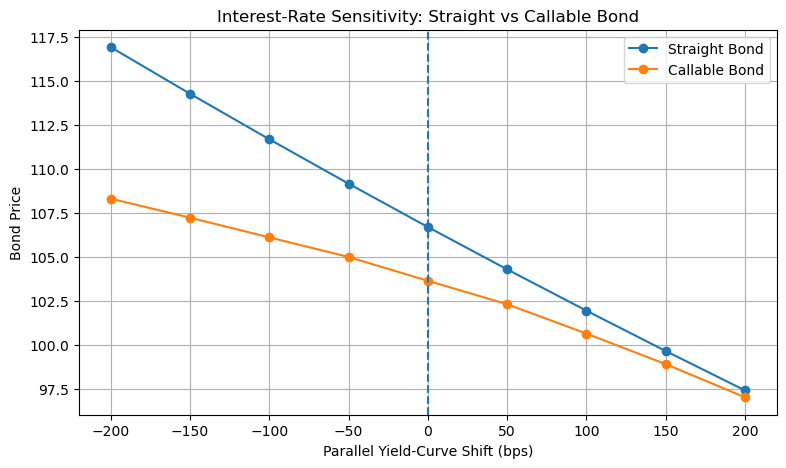

In [79]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    rate_shifts_bps,
    straight_prices_scenarios,
    marker="o",
    label="Straight Bond"
)

plt.plot(
    rate_shifts_bps,
    callable_prices_scenarios,
    marker="o",
    label="Callable Bond"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Parallel Yield-Curve Shift (bps)"
)

plt.ylabel(
    "Bond Price"
)

plt.title(
    "Interest-Rate Sensitivity: Straight vs Callable Bond"
)

plt.legend()
plt.grid(True)

plt.show()

#### Interpretation

The interest-rate scenarios highlight the asymmetric risk profile created by the embedded call option.

The straight bond exhibits the usual positively convex price-yield relationship: its price increases increasingly as interest rates decline.

The callable bond behaves differently. When interest rates fall, the continuation value of the bond increases and the issuer's call option becomes more valuable. The probability of exercise therefore increases, limiting the price appreciation of the callable bond.

Conversely, when interest rates rise, the call option moves out of the money and the callable bond increasingly behaves like the equivalent straight bond.

The embedded option therefore creates an asymmetric exposure to interest rates: the investor retains much of the downside associated with rising rates while giving up part of the upside associated with falling rates.

### 8.2 Duration and DV01

Interest-rate sensitivity can be quantified using finite differences.

The DV01 measures the approximate change in the bond price for a one-basis-point increase in interest rates.

Using a symmetric rate shock:

$$
DV01
\approx
\frac{P(r-\Delta r)-P(r+\Delta r)}
{2\Delta r}
\times 0.0001
$$

where $\Delta r$ is expressed in decimal form.

The effective duration is:

$$
D_{\text{eff}}
=
\frac{
P(r-\Delta r)-P(r+\Delta r)
}{
2P_0\Delta r
}
$$

For callable bonds, effective duration is particularly useful because the bond's future cash flows depend on the issuer's exercise decision.

In [80]:
# Locate the relevant scenarios
index_minus_50 = np.where(
    rate_shifts_bps == -50
)[0][0]

index_zero = np.where(
    rate_shifts_bps == 0
)[0][0]

index_plus_50 = np.where(
    rate_shifts_bps == 50
)[0][0]

In [81]:
# Straight bond prices
straight_minus = (
    straight_prices_scenarios[
        index_minus_50
    ]
)

straight_base = (
    straight_prices_scenarios[
        index_zero
    ]
)

straight_plus = (
    straight_prices_scenarios[
        index_plus_50
    ]
)

# Callable bond prices
callable_minus = (
    callable_prices_scenarios[
        index_minus_50
    ]
)

callable_base = (
    callable_prices_scenarios[
        index_zero
    ]
)

callable_plus = (
    callable_prices_scenarios[
        index_plus_50
    ]
)

In [82]:
delta_r = 0.005

In [83]:
straight_duration = (
    straight_minus
    - straight_plus
) / (
    2
    * straight_base
    * delta_r
)

callable_duration = (
    callable_minus
    - callable_plus
) / (
    2
    * callable_base
    * delta_r
)

print(
    f"Straight bond effective duration: "
    f"{straight_duration:.4f}"
)

print(
    f"Callable bond effective duration: "
    f"{callable_duration:.4f}"
)

Straight bond effective duration: 4.5582
Callable bond effective duration: 2.5874


In [84]:
straight_dv01 = (
    straight_minus
    - straight_plus
) / (
    2 * delta_r
) * 0.0001

callable_dv01 = (
    callable_minus
    - callable_plus
) / (
    2 * delta_r
) * 0.0001

print(
    f"Straight bond DV01: "
    f"{straight_dv01:.6f}"
)

print(
    f"Callable bond DV01: "
    f"{callable_dv01:.6f}"
)

Straight bond DV01: 0.048629
Callable bond DV01: 0.026814


### Interpretation

The callable bond exhibits significantly lower interest-rate sensitivity than the equivalent straight bond.

The effective duration decreases from approximately **4.56** for the straight bond to **2.59** for the callable bond, while DV01 decreases from approximately **0.0486** to **0.0268**.

This reduction results from the embedded issuer call. When interest rates decline, the probability of early redemption increases, limiting the investor's exposure to future cash flows.

The two-year call protection prevents the issuer from redeeming the bond during the first two years, which preserves a meaningful amount of interest-rate exposure. After the non-call period, however, the effective maturity of the bond becomes state-dependent because the issuer may exercise the call.

Therefore, the callable bond's duration and DV01 are not static characteristics: they depend on the level of interest rates and on the probability of future exercise.

### 8.3 Convexity

Duration provides a first-order approximation of the sensitivity of a bond price to interest rates. However, the relationship between bond prices and interest rates is non-linear.

Effective convexity captures this curvature and can be approximated using symmetric interest-rate shocks:

$$
C_{\text{eff}}
=
\frac{
P(r-\Delta r)
+
P(r+\Delta r)
-
2P_0
}{
P_0(\Delta r)^2
}
$$

A standard straight bond generally exhibits positive convexity.

For a callable bond, the embedded call option limits price appreciation when interest rates decline. As a result, the callable bond may exhibit substantially lower convexity and can even display negative convexity in regions where the call option becomes particularly important.

In [85]:
# Compute effective convexity
straight_convexity = (
    straight_minus
    + straight_plus
    - 2 * straight_base
) / (
    straight_base
    * delta_r**2
)

callable_convexity = (
    callable_minus
    + callable_plus
    - 2 * callable_base
) / (
    callable_base
    * delta_r**2
)

print(
    f"Straight bond effective convexity: "
    f"{straight_convexity:.4f}"
)

print(
    f"Callable bond effective convexity: "
    f"{callable_convexity:.4f}"
)

Straight bond effective convexity: 21.9205
Callable bond effective convexity: 8.0575


### Interpretation

The straight bond exhibits positive convexity, with an effective convexity of approximately **21.92**.

The callable bond also exhibits positive convexity around the current market scenario, but at a significantly lower level of approximately **8.06**.

The embedded issuer call therefore reduces the positive convexity of the bond. As interest rates decline and the probability of early redemption increases, part of the price appreciation that would otherwise occur for the straight bond is capped by the call feature.

Importantly, a callable bond does not necessarily exhibit negative convexity in every interest-rate environment. Its convexity depends on the level of rates, the call schedule, volatility and the proximity to the exercise boundary. When the embedded call becomes sufficiently relevant, the callable bond may exhibit negative convexity.

### 8.4 Volatility Sensitivity

Interest-rate volatility is a key risk factor for callable bonds because the investor is effectively short the issuer's embedded call option.

An increase in interest-rate volatility increases the probability of reaching interest-rate states in which exercising the call becomes valuable to the issuer.

Therefore:

$$
\sigma \uparrow
\quad\Rightarrow\quad
V_{\text{Call}} \uparrow
$$

and, since:

$$
P_{\text{Callable}}
=
P_{\text{Straight}}
-
V_{\text{Call}},
$$

we expect:

$$
\sigma \uparrow
\quad\Rightarrow\quad
P_{\text{Callable}} \downarrow.
$$

By contrast, the value of the equivalent straight bond should remain approximately unchanged because the Hull–White tree is recalibrated to the same initial discount curve for each volatility scenario.

In [86]:
# Hull-White volatility scenarios
sigma_scenarios = np.array([
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030
])

straight_prices_vol = []
callable_prices_vol = []
embedded_call_values_vol = []

In [87]:
for sigma_scenario in sigma_scenarios:

    # Rebuild and recalibrate the Hull-White tree
    (
        scenario_times,
        scenario_x_tree,
        scenario_rate_tree,
        scenario_probabilities,
        scenario_discount_factors
    ) = build_hull_white_tree(
        zero_curve_spline=zero_curve_spline,
        maturity=maturity,
        a=a,
        sigma=sigma_scenario,
        dt=dt_hw
    )

    # Reprice the straight and callable bonds
    (
        scenario_straight_price,
        scenario_callable_price
    ) = price_bonds_from_tree(
        rate_tree=scenario_rate_tree,
        transition_probabilities=scenario_probabilities,
        times=scenario_times,
        notional=100,
        coupon_rate=0.05,
        call_dates=call_dates_hw,
        call_price=100,
        dt=dt_hw
    )

    # Value of the embedded issuer call option
    embedded_call_value = (
        scenario_straight_price
        - scenario_callable_price
    )

    straight_prices_vol.append(
        scenario_straight_price
    )

    callable_prices_vol.append(
        scenario_callable_price
    )

    embedded_call_values_vol.append(
        embedded_call_value
    )

In [88]:
for (
    sigma_scenario,
    straight_price,
    callable_price,
    call_value
) in zip(
    sigma_scenarios,
    straight_prices_vol,
    callable_prices_vol,
    embedded_call_values_vol
):

    print(
        f"Sigma = {sigma_scenario * 100:4.1f}% | "
        f"Straight = {straight_price:7.3f} | "
        f"Callable = {callable_price:7.3f} | "
        f"Call Value = {call_value:6.3f}"
    )

Sigma =  0.5% | Straight = 106.685 | Callable = 104.101 | Call Value =  2.584
Sigma =  1.0% | Straight = 106.685 | Callable = 103.634 | Call Value =  3.051
Sigma =  1.5% | Straight = 106.685 | Callable = 103.058 | Call Value =  3.627
Sigma =  2.0% | Straight = 106.685 | Callable = 102.494 | Call Value =  4.191
Sigma =  2.5% | Straight = 106.685 | Callable = 101.893 | Call Value =  4.792
Sigma =  3.0% | Straight = 106.685 | Callable = 101.163 | Call Value =  5.522


### Interpretation

The straight bond value remains approximately constant at **106.685** across the volatility scenarios because its contractual cash flows are deterministic and each Hull–White tree is recalibrated to the same initial yield curve.

The callable bond, however, decreases in value as the Hull–White volatility parameter increases. When $\sigma$ rises from **0.5% to 3.0%**, the callable bond value decreases from approximately **104.10 to 101.16**, while the value of the embedded issuer call increases from approximately **2.58 to 5.52**.

Economically:

$$
\sigma \uparrow
\quad \Rightarrow \quad
V_{\text{Call}} \uparrow
\quad \Rightarrow \quad
V_{\text{Callable}} \downarrow.
$$

The investor in the callable bond is therefore effectively short the embedded interest-rate option and is negatively exposed to increases in interest-rate volatility.

The parameter $\sigma$ used here represents the volatility parameter of the Hull–White short-rate model rather than a directly quoted market vega. In a production setting, model parameters would typically be calibrated to market prices or implied volatilities of liquid interest-rate options such as swaptions.

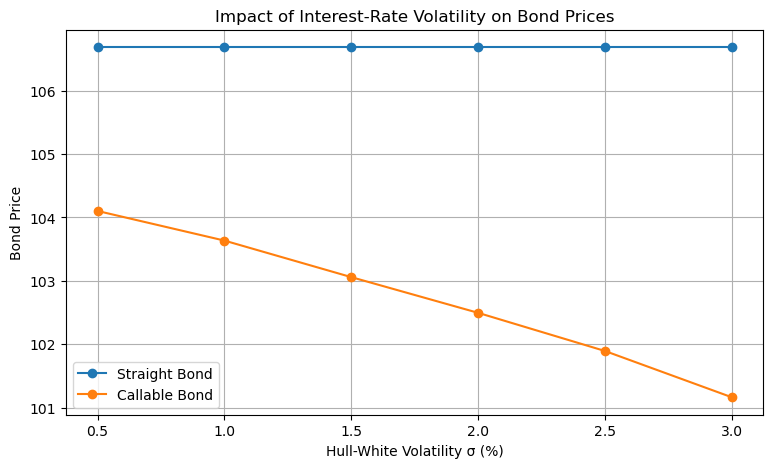

In [89]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    sigma_scenarios * 100,
    straight_prices_vol,
    marker="o",
    label="Straight Bond"
)

plt.plot(
    sigma_scenarios * 100,
    callable_prices_vol,
    marker="o",
    label="Callable Bond"
)

plt.xlabel(
    "Hull-White Volatility σ (%)"
)

plt.ylabel(
    "Bond Price"
)

plt.title(
    "Impact of Interest-Rate Volatility on Bond Prices"
)

plt.legend()
plt.grid(True)

plt.show()

## 9. Trading and Risk-Management Interpretation

The callable bond can be interpreted as a combination of a straight fixed-rate bond and a short position in an interest-rate option:

$$
P_{\text{Callable}}
=
P_{\text{Straight}}
-
V_{\text{Call}}
$$

This decomposition is useful not only for pricing but also for understanding the risk profile of the instrument.

The numerical results obtained in the previous sections show that the embedded call option materially changes both the interest-rate and volatility exposure of the bond.

### 9.1 Interest-Rate Risk

The callable bond has significantly less interest-rate sensitivity than the equivalent straight bond.

In the base scenario, the effective duration decreases from approximately:

$$
D_{\text{Straight}} = 4.56
$$

to:

$$
D_{\text{Callable}} = 2.59
$$

while the DV01 decreases from approximately:

$$
DV01_{\text{Straight}} = 0.0486
$$

to:

$$
DV01_{\text{Callable}} = 0.0268.
$$

The embedded call option therefore substantially reduces the callable bond's local exposure to parallel movements in the yield curve.

However, this exposure is not constant. During the two-year non-call period, the issuer cannot exercise the option. After the call protection period, when interest rates decline, the probability of exercise increases and the bond's expected maturity shortens. When rates rise, the call option becomes less relevant and the callable bond increasingly behaves like a straight bond.

The callable bond therefore has a state-dependent interest-rate exposure.

### 9.2 Convexity and Volatility Risk

The embedded call option also modifies the convexity profile of the bond.

In the base scenario, the straight bond has an effective convexity of approximately:

$$
C_{\text{Straight}} = 21.92
$$

while the callable bond has an effective convexity of approximately:

$$
C_{\text{Callable}} = 8.06.
$$

The callable bond therefore retains positive convexity around the current market scenario, but significantly less than the equivalent straight bond.

When interest rates decline, the probability of early redemption increases. This limits the price appreciation of the callable bond relative to the straight bond and progressively reduces its convexity.

Importantly, a callable bond does not necessarily exhibit negative convexity in every interest-rate environment. Its convexity depends on the level of interest rates, the call schedule, volatility, and the proximity to the exercise boundary. If the embedded call becomes sufficiently relevant, the callable bond may exhibit negative convexity.

The callable bond can be interpreted as:

$$
\text{Callable Bond}
=
\text{Straight Bond}
-
\text{Issuer Call Option}.
$$

The investor is therefore short the embedded optionality.

This is also visible in the volatility analysis. As the Hull–White volatility parameter increases from:

$$
\sigma = 0.5\%
$$

to:

$$
\sigma = 3.0\%,
$$

the value of the embedded call increases from approximately:

$$
V_{\text{Call}} = 2.58
$$

to:

$$
V_{\text{Call}} = 5.52,
$$

while the callable bond value decreases from approximately:

$$
V_{\text{Callable}} = 104.10
$$

to:

$$
V_{\text{Callable}} = 101.16.
$$

Higher interest-rate volatility therefore benefits the issuer through the embedded call option and negatively affects the investor holding the callable bond.

### 9.3 Hedging Interpretation

From a trading and risk-management perspective, the callable bond cannot be hedged using only the static interest-rate sensitivity of an equivalent straight bond.

A first-order hedge can be constructed using government bonds or interest-rate swaps to offset the callable bond's DV01.

In the base scenario, the callable bond has a DV01 of approximately:

$$
DV01_{\text{Callable}} = 0.0268.
$$

A trader could therefore construct an interest-rate hedge with an opposite DV01 exposure.

However, a DV01-neutral position is not fully hedged.

As interest rates move, the probability of exercise changes, which modifies the expected maturity of the callable bond and therefore its duration and DV01. The hedge must consequently be adjusted dynamically.

In addition, the embedded call creates convexity and volatility exposure that cannot be captured by a simple linear DV01 hedge.

Interest-rate options such as swaptions can therefore be used to manage part of the optionality and volatility risk generated by the issuer's call feature.

The risk-management problem can therefore be viewed as a combination of:

$$
\text{Interest-Rate Risk}
+
\text{Convexity Risk}
+
\text{Volatility Risk}.
$$

This makes the callable bond more complex to hedge than an otherwise equivalent straight bond and requires dynamic risk management as market conditions and exercise probabilities evolve.

## 10. Model Limitations

The framework developed in this project is designed to capture the main economic mechanisms of callable bond pricing and risk management rather than to reproduce a full production-level pricing library.

The interest-rate dynamics are represented using a simplified one-factor Hull–White trinomial tree calibrated to an illustrative zero-coupon curve. The mean-reversion and volatility parameters are treated as model inputs rather than being calibrated to a market surface of interest-rate options.

The callable bond is modeled as a five-year fixed-rate bond with two years of call protection, followed by annual call opportunities at par on coupon payment dates. This simplified structure avoids additional contractual features such as irregular call schedules, accrued-interest conventions, day-count conventions, settlement rules, and business-day adjustments.

In a production environment, the initial yield curve would typically be constructed from liquid market instruments, while the Hull–White parameters would be calibrated to market prices or implied volatilities of interest-rate derivatives such as swaptions.

Additional factors such as issuer credit risk, liquidity, transaction costs, funding considerations, and more complex contractual features would also need to be incorporated for a complete market valuation.

## 11. Conclusion

This project developed a pricing and risk-management framework for a five-year fixed-rate callable bond with two years of call protection and annual call opportunities thereafter.

The initial yield curve was incorporated into a one-factor Hull–White short-rate model using a recombining trinomial tree calibrated through Arrow-Debreu state prices. The straight and callable bonds were then valued by backward induction under risk-neutral probabilities.

Under the base-case assumptions, the straight bond is valued at approximately:

$$
V_{\text{Straight}} = 106.68,
$$

while the callable bond is valued at approximately:

$$
V_{\text{Callable}} = 103.63.
$$

The value of the embedded issuer call is therefore approximately:

$$
V_{\text{Call}} = 3.05.
$$

The embedded call materially changes the interest-rate risk profile of the bond.

Effective duration decreases from:

$$
D_{\text{Straight}} = 4.56
$$

to:

$$
D_{\text{Callable}} = 2.59,
$$

while DV01 decreases from:

$$
DV01_{\text{Straight}} = 0.0486
$$

to:

$$
DV01_{\text{Callable}} = 0.0268.
$$

The call feature also reduces the convexity of the bond. In the base scenario, effective convexity decreases from approximately:

$$
C_{\text{Straight}} = 21.92
$$

to:

$$
C_{\text{Callable}} = 8.06.
$$

The callable bond therefore retains positive convexity around the current market scenario, but substantially less than the equivalent straight bond. Its convexity may become negative in market environments where the embedded call becomes sufficiently relevant.

The volatility analysis further illustrates the embedded optionality. As the Hull–White volatility parameter increases, the value of the issuer's call option increases while the value of the callable bond decreases.

This relationship follows directly from:

$$
\text{Callable Bond}
=
\text{Straight Bond}
-
\text{Issuer Call Option}.
$$

From a trading and risk-management perspective, the callable bond therefore combines conventional interest-rate exposure with embedded optionality. Its duration, DV01, convexity, and volatility exposure evolve with market conditions and exercise probabilities.

Consequently, managing a callable bond requires more than a static interest-rate hedge: the position must be monitored and dynamically rebalanced as the embedded option moves through different exercise regimes.